In [ ]:
# ==================== 第一部分：导入库和配置 ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')
import os
from datetime import datetime, timedelta
from scipy import stats
import pickle
import json

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# 创建输出目录
output_dirs = ['models', 'plots', 'csv', 'reports', 'predictions']
for dir_name in output_dirs:
    os.makedirs(f'stk_RF-SVM/{dir_name}', exist_ok=True)

print("="*60)
print("环境配置完成！")
print(f"输出目录已创建: {', '.join(output_dirs)}")
print("="*60)

环境配置完成！
输出目录已创建: models, plots, csv, reports, predictions


In [5]:
# ==================== 第二部分：数据加载和预处理====================
def load_and_preprocess_data(file_path):
    """加载数据并进行预处理，计算缺失的未来收益率"""
    print("正在加载数据...")
    df = pd.read_csv(file_path)
    print(f"原始数据形状: {df.shape}")
    print(f"原始数据列: {df.columns.tolist()}")
    
    # 转换日期格式
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)
    
    print(f"\n原始数据中有 future_5d_return，需要计算 future_10d_return 和 future_20d_return")
    
    # 计算未来收益率
    print("\n计算未来收益率...")
    
    # 获取所有股票代码
    stock_codes = df['ts_code'].unique()
    print(f"共有 {len(stock_codes)} 只股票")
    
    # 为每个股票计算未来收益率
    all_dfs = []
    for i, stock_code in enumerate(stock_codes):
        if i % 50 == 0:
            print(f"  处理第 {i+1}/{len(stock_codes)} 只股票...")
        
        # 获取该股票的数据
        stock_df = df[df['ts_code'] == stock_code].sort_values('trade_date').reset_index(drop=True)
        
        # 获取收盘价序列
        close_prices = stock_df['close'].values
        n = len(stock_df)
        
        # 计算未来收益率
        future_5d = np.full(n, np.nan)
        future_10d = np.full(n, np.nan)
        future_20d = np.full(n, np.nan)
        
        for idx in range(n):
            # 未来5日收益率
            if idx + 5 < n and close_prices[idx] > 0 and not np.isnan(close_prices[idx + 5]):
                future_5d[idx] = (close_prices[idx + 5] / close_prices[idx]) - 1
            
            # 未来10日收益率
            if idx + 10 < n and close_prices[idx] > 0 and not np.isnan(close_prices[idx + 10]):
                future_10d[idx] = (close_prices[idx + 10] / close_prices[idx]) - 1
            
            # 未来20日收益率
            if idx + 20 < n and close_prices[idx] > 0 and not np.isnan(close_prices[idx + 20]):
                future_20d[idx] = (close_prices[idx + 20] / close_prices[idx]) - 1
        
        # 添加到DataFrame
        stock_df['future_5d_return'] = future_5d
        stock_df['future_10d_return'] = future_10d
        stock_df['future_20d_return'] = future_20d
        
        all_dfs.append(stock_df)
    
    # 合并所有股票数据
    df = pd.concat(all_dfs, ignore_index=True)
    print(f"计算完成，数据形状: {df.shape}")
    
    # 处理缺失值：使用向前填充和向后填充
    print("\n处理缺失值...")
    
    # 先处理未来收益率列的缺失值
    future_cols = ['future_5d_return', 'future_10d_return', 'future_20d_return']
    
    for col in future_cols:
        if col in df.columns:
            print(f"处理 {col} 的缺失值...")
            
            # 对每个股票分组进行填充
            for stock_code in df['ts_code'].unique():
                mask = df['ts_code'] == stock_code
                # 向前填充 - 使用ffill()
                df.loc[mask, col] = df.loc[mask, col].ffill()
                # 向后填充 - 使用bfill()
                df.loc[mask, col] = df.loc[mask, col].bfill()
            
            # 将剩余NaN填充为0
            df[col] = df[col].fillna(0)
            
            # 统计非零值
            non_zero = (df[col] != 0).sum()
            print(f"  {col}: 非零值数量 {non_zero}/{len(df)} ({non_zero/len(df)*100:.2f}%)")
        else:
            print(f"警告: {col} 不存在")
    
    # 处理其他特征列的缺失值
    print("\n处理特征列缺失值...")
    feature_cols = [col for col in df.columns if col not in ['ts_code', 'trade_date', 'year_month'] + future_cols]
    
    for col in feature_cols:
        try:
            print(f"  处理特征列: {col}")
            # 对每个股票分组进行填充
            for stock_code in df['ts_code'].unique():
                mask = df['ts_code'] == stock_code
                # 向前填充
                df.loc[mask, col] = df.loc[mask, col].ffill()
                # 向后填充
                df.loc[mask, col] = df.loc[mask, col].bfill()
            # 将剩余NaN填充为0
            df[col] = df[col].fillna(0)
        except Exception as e:
            print(f"  处理列 {col} 时出错: {e}, 使用全局填充")
            df[col] = df[col].ffill()
            df[col] = df[col].bfill()
            df[col] = df[col].fillna(0)
    
    # 删除可能包含inf的列
    df = df.replace([np.inf, -np.inf], 0)
    
    print(f"\n处理后数据形状: {df.shape}")
    print(f"日期范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")
    print(f"股票数量: {df['ts_code'].nunique()}")
    
    # 检查最终数据
    print("\n最终数据统计:")
    print(f"总行数: {len(df)}")
    print(f"列数: {len(df.columns)}")
    print("\n未来收益率统计:")
    for col in ['future_5d_return', 'future_10d_return', 'future_20d_return']:
        if col in df.columns:
            valid_data = df[col][df[col] != 0]
            if len(valid_data) > 0:
                print(f"  {col}: 均值={valid_data.mean():.6f}, 标准差={valid_data.std():.6f}, 范围=[{valid_data.min():.6f}, {valid_data.max():.6f}]")
                print(f"    非零值: {len(valid_data)}/{len(df)} ({len(valid_data)/len(df)*100:.2f}%)")
            else:
                print(f"  {col}: 全为零")
    
    # 验证计算是否正确
    print("\n验证计算结果（前10行）:")
    print(df[['ts_code', 'trade_date', 'close', 'future_5d_return', 'future_10d_return', 'future_20d_return']].head(10))
    
    return df

# 加载并处理数据
df = load_and_preprocess_data('../extracted_data/selected_factors_with_data1.csv')
print("="*60)

正在加载数据...
原始数据形状: (23979, 36)
原始数据列: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'vol', 'amount', 'pre_close', 'pct_chg', 'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio', 'auto_kurtosis_20', 'hist_vol_60', 'auto_volatility_20', 'hist_vol_20', 'auto_volatility_60', 'auto_std_60_1', 'auto_amount_ma_30', 'auto_open_ratio_60', 'auto_quantile_0.75_30', 'auto_amount_ma_60', 'auto_skew_30_1', 'auto_kurtosis_20_1', 'auto_volatility_20_1', 'auto_volatility_60_1', 'auto_std_60', 'auto_amount_ma_30_1', 'auto_open_ratio_60_1', 'auto_open_log_return_60', 'auto_open_log_return_60_1', 'auto_quantile_0.75_30_1', 'future_5d_return', 'year_month']

原始数据中有 future_5d_return，需要计算 future_10d_return 和 future_20d_return

计算未来收益率...
共有 100 只股票
  处理第 1/100 只股票...
  处理第 51/100 只股票...
计算完成，数据形状: (23979, 38)

处理缺失值...
处理 future_5d_return 的缺失值...
  future_5d_return: 非零值数量 23735/23979 (98.98%)
处理 future_10d_return 的缺失值...
  future_10d_return: 非零值数量 23807/23979 (99.28%)
处理 future_20d_return

In [6]:
# ==================== 数据完整性检查 ====================
print("\n数据完整性检查:")
print("-"*60)

# 检查所有未来收益率列
future_cols = ['future_5d_return', 'future_10d_return', 'future_20d_return']
for col in future_cols:
    if col in df.columns:
        non_zero = (df[col] != 0).sum()
        print(f"{col}: 存在, 非零值: {non_zero}/{len(df)} ({non_zero/len(df)*100:.2f}%)")
        if non_zero > 0:
            valid_data = df[col][df[col] != 0]
            print(f"  均值: {valid_data.mean():.6f}")
            print(f"  标准差: {valid_data.std():.6f}")
            print(f"  范围: [{valid_data.min():.6f}, {valid_data.max():.6f}]")
    else:
        print(f"{col}: 不存在")

# 检查每个股票的数据量
stock_counts = df.groupby('ts_code').size()
print(f"\n每只股票样本数: 均值={stock_counts.mean():.1f}, 范围=[{stock_counts.min()}, {stock_counts.max()}]")

# 检查是否有股票数据不足
insufficient = stock_counts[stock_counts < 20]
if len(insufficient) > 0:
    print(f"警告: {len(insufficient)} 只股票数据不足20个交易日")
    print(f"这些股票示例: {insufficient.index.tolist()[:5]}")
else:
    print("所有股票数据充足（>=20个交易日）")

print("="*60)


数据完整性检查:
------------------------------------------------------------
future_5d_return: 存在, 非零值: 23735/23979 (98.98%)
  均值: 0.000792
  标准差: 0.088114
  范围: [-0.432526, 1.609489]
future_10d_return: 存在, 非零值: 23807/23979 (99.28%)
  均值: -0.000378
  标准差: 0.124310
  范围: [-0.465918, 2.264840]
future_20d_return: 存在, 非零值: 23869/23979 (99.54%)
  均值: -0.000091
  标准差: 0.180421
  范围: [-0.603509, 2.325581]

每只股票样本数: 均值=239.8, 范围=[40, 249]
所有股票数据充足（>=20个交易日）


In [7]:
# ==================== 第三部分：特征工程和标签定义 ====================
def prepare_features_and_labels(df, lookback_days=[5, 10, 20]):
    """准备特征和标签"""
    print("\n准备特征和标签...")
    
    # 定义特征列（排除非特征列）
    exclude_cols = ['ts_code', 'trade_date', 'year_month']
    
    # 添加所有未来收益率列到排除列表
    future_cols = ['future_5d_return', 'future_10d_return', 'future_20d_return']
    for col in future_cols:
        if col in df.columns:
            exclude_cols.append(col)
    
    # 获取特征列
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    print(f"特征数量: {len(feature_cols)}")
    print(f"特征列示例: {feature_cols[:10]}...")
    if len(feature_cols) <= 10:
        print(f"特征列完整列表: {feature_cols}")
    print(f"排除的列: {exclude_cols}")
    
    # 创建多个时间窗口的标签
    labels_dict = {}
    for days in lookback_days:
        col_name = f'future_{days}d_return'
        if col_name in df.columns:
            # 回归标签：未来收益率
            labels_dict[f'future_{days}d_return'] = df[col_name].values
            # 分类标签：涨跌（1表示涨，0表示跌）
            labels_dict[f'future_{days}d_class'] = (df[col_name] > 0).astype(int).values
            
            # 统计标签分布
            positive = np.sum(labels_dict[f'future_{days}d_class'] == 1)
            negative = np.sum(labels_dict[f'future_{days}d_class'] == 0)
            total = positive + negative
            if total > 0:
                print(f"  {col_name}: 上涨{positive}次, 下跌{negative}次, 比例={positive/(positive+negative):.2%}")
            else:
                print(f"  {col_name}: 所有标签为零")
        else:
            print(f"警告: {col_name} 不存在，创建占位标签")
            labels_dict[f'future_{days}d_return'] = np.zeros(len(df))
            labels_dict[f'future_{days}d_class'] = np.zeros(len(df), dtype=int)
    
    # 提取特征矩阵
    X = df[feature_cols].values
    dates = df['trade_date'].values
    codes = df['ts_code'].values
    
    print(f"\n特征矩阵形状: {X.shape}")
    print(f"日期范围: {dates.min()} 到 {dates.max()}")
    print("标签准备完成！")
    
    return X, labels_dict, dates, codes, feature_cols

X, labels_dict, dates, codes, feature_cols = prepare_features_and_labels(df)
print("="*60)


准备特征和标签...
特征数量: 32
特征列示例: ['open', 'high', 'low', 'close', 'vol', 'amount', 'pre_close', 'pct_chg', 'daily_return', 'turnover_rate']...
排除的列: ['ts_code', 'trade_date', 'year_month', 'future_5d_return', 'future_10d_return', 'future_20d_return']
  future_5d_return: 上涨10695次, 下跌13284次, 比例=44.60%
  future_10d_return: 上涨10508次, 下跌13471次, 比例=43.82%
  future_20d_return: 上涨10576次, 下跌13403次, 比例=44.11%

特征矩阵形状: (23979, 32)
日期范围: 2024-01-02T00:00:00.000000 到 2025-01-10T00:00:00.000000
标签准备完成！


In [11]:
# ==================== 第四部分：滚动窗口训练集构建====================
print("\n数据时间范围分析:")
print("-"*60)

# 确保dates是datetime类型
if isinstance(dates[0], np.datetime64):
    dates_dt = pd.to_datetime(dates)
else:
    dates_dt = pd.to_datetime(dates)

print(f"数据起始日期: {dates_dt.min()}")
print(f"数据结束日期: {dates_dt.max()}")
print(f"总天数: {(dates_dt.max() - dates_dt.min()).days} 天")
print(f"总样本数: {len(dates_dt)}")

# 计算实际交易日数
unique_dates = sorted(np.unique(dates_dt))
print(f"实际交易日数: {len(unique_dates)}")
print(f"第一个交易日: {unique_dates[0]}")
print(f"最后一个交易日: {unique_dates[-1]}")

# 使用适合短期数据的滚动窗口参数
def create_rolling_windows_short_term(dates, train_months=3, test_months=1, step_days=20):
    """
    为短期数据创建滚动窗口
    train_months: 训练集月份数
    test_months: 测试集月份数
    step_days: 滑动步长（天）
    """
    print(f"\n创建短期滚动窗口 (训练{train_months}个月, 测试{test_months}个月)...")
    
    # 确保dates是datetime类型
    if isinstance(dates[0], np.datetime64):
        dates_dt = pd.to_datetime(dates)
    else:
        dates_dt = pd.to_datetime(dates)
    
    unique_dates = sorted(np.unique(dates_dt))
    train_days = train_months * 21  # 每月约21个交易日
    test_days = test_months * 21
    
    print(f"训练天数: {train_days} (约{train_months}个月)")
    print(f"测试天数: {test_days} (约{test_months}个月)")
    print(f"滑动步长: {step_days}天")
    
    windows = []
    
    # 从最早日期开始滑动
    for i in range(0, len(unique_dates) - train_days - test_days, step_days):
        train_start_idx = i
        train_end_idx = i + train_days
        test_end_idx = i + train_days + test_days
        
        # 确保索引不越界
        if test_end_idx >= len(unique_dates):
            break
        
        # 获取日期
        train_start = unique_dates[train_start_idx]
        train_end = unique_dates[train_end_idx]
        test_start = unique_dates[train_end_idx]
        test_end = unique_dates[test_end_idx]
        
        # 获取训练集和测试集的索引
        train_indices = np.where((dates_dt >= train_start) & (dates_dt < train_end))[0]
        test_indices = np.where((dates_dt >= test_start) & (dates_dt < test_end))[0]
        
        # 检查样本数量是否足够
        if len(train_indices) >= 50 and len(test_indices) >= 10:
            windows.append({
                'train_start': train_start,
                'train_end': train_end,
                'test_start': test_start,
                'test_end': test_end,
                'train_indices': train_indices,
                'test_indices': test_indices,
                'n_train': len(train_indices),
                'n_test': len(test_indices)
            })
            print(f"  窗口 {len(windows)}: 训练 {len(train_indices)} 样本, 测试 {len(test_indices)} 样本")
            # 使用pd.to_datetime转换后再格式化
            print(f"    训练期: {pd.to_datetime(train_start).strftime('%Y-%m-%d')} 到 {pd.to_datetime(train_end).strftime('%Y-%m-%d')}")
            print(f"    测试期: {pd.to_datetime(test_start).strftime('%Y-%m-%d')} 到 {pd.to_datetime(test_end).strftime('%Y-%m-%d')}")
    
    print(f"\n共创建 {len(windows)} 个滚动窗口")
    return windows

# 创建短期滚动窗口（3个月训练，1个月测试）
windows = create_rolling_windows_short_term(dates_dt, train_months=3, test_months=1, step_days=20)




数据时间范围分析:
------------------------------------------------------------
数据起始日期: 2024-01-02 00:00:00
数据结束日期: 2025-01-10 00:00:00
总天数: 374 天
总样本数: 23979
实际交易日数: 249
第一个交易日: 2024-01-02T00:00:00.000000
最后一个交易日: 2025-01-10T00:00:00.000000

创建短期滚动窗口 (训练3个月, 测试1个月)...
训练天数: 63 (约3个月)
测试天数: 21 (约1个月)
滑动步长: 20天
  窗口 1: 训练 6071 样本, 测试 2001 样本
    训练期: 2024-01-02 到 2024-04-10
    测试期: 2024-04-10 到 2024-05-14
  窗口 2: 训练 6001 样本, 测试 2054 样本
    训练期: 2024-01-30 到 2024-05-13
    测试期: 2024-05-13 到 2024-06-12
  窗口 3: 训练 6109 样本, 测试 2056 样本
    训练期: 2024-03-06 到 2024-06-11
    测试期: 2024-06-11 到 2024-07-10
  窗口 4: 训练 6112 样本, 测试 2057 样本
    训练期: 2024-04-03 到 2024-07-09
    测试期: 2024-07-09 到 2024-08-07
  窗口 5: 训练 6169 样本, 测试 2061 样本
    训练期: 2024-05-08 到 2024-08-06
    测试期: 2024-08-06 到 2024-09-04
  窗口 6: 训练 6171 样本, 测试 1914 样本
    训练期: 2024-06-05 到 2024-09-03
    测试期: 2024-09-03 到 2024-10-11
  窗口 7: 训练 6036 样本, 测试 1983 样本
    训练期: 2024-07-04 到 2024-10-10
    测试期: 2024-10-10 到 2024-11-08
  窗口 8: 训练 5959 样

In [16]:
# ==================== 回测与评估函数 ====================
def backtest_strategy(predictions_df, top_n=50, transaction_cost=0.001):
    """回测选股策略"""
    print(f"\n{'='*60}")
    print("开始回测评估")
    print(f"选股数量: Top {top_n}")
    print(f"交易成本: {transaction_cost*100:.2f}%")
    print(f"{'='*60}")
    
    if predictions_df is None or len(predictions_df) == 0:
        print("错误: 预测结果为空")
        return None
    
    print(f"预测结果形状: {predictions_df.shape}")
    print(f"日期范围: {predictions_df['date'].min()} 到 {predictions_df['date'].max()}")
    
    # 按日期分组
    daily_results = []
    
    for date in sorted(predictions_df['date'].unique()):
        day_data = predictions_df[predictions_df['date'] == date].copy()
        
        # 按预测收益率排序，选择Top N
        day_data = day_data.sort_values('ensemble_pred', ascending=False)
        top_stocks = day_data.head(top_n)
        
        # 计算当日收益（等权重）
        if len(top_stocks) > 0:
            avg_return = top_stocks['y_true'].mean()
            # 扣除交易成本
            net_return = avg_return - transaction_cost
        else:
            net_return = 0
        
        daily_results.append({
            'date': date,
            'return': net_return,
            'n_stocks': len(top_stocks),
            'avg_pred_return': top_stocks['ensemble_pred'].mean() if len(top_stocks) > 0 else 0,
            'avg_true_return': top_stocks['y_true'].mean() if len(top_stocks) > 0 else 0
        })
    
    if len(daily_results) == 0:
        print("错误: 没有有效的回测数据")
        return None
    
    daily_df = pd.DataFrame(daily_results)
    daily_df['cumulative_return'] = (1 + daily_df['return']).cumprod()
    
    # 计算评估指标
    total_return = daily_df['cumulative_return'].iloc[-1] - 1 if len(daily_df) > 0 else 0
    annualized_return = (1 + total_return) ** (252 / len(daily_df)) - 1 if len(daily_df) > 0 else 0
    daily_volatility = daily_df['return'].std() * np.sqrt(252) if len(daily_df) > 0 else 0
    sharpe_ratio = annualized_return / daily_volatility if daily_volatility > 0 else 0
    
    # 最大回撤
    cumulative = daily_df['cumulative_return'].values
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
    
    # IC计算（预测收益率与实际收益率的相关系数）
    ic = daily_df['avg_pred_return'].corr(daily_df['avg_true_return']) if len(daily_df) > 1 else 0
    
    # 预测准确率
    if 'ensemble_proba' in predictions_df.columns:
        predictions_df['pred_class'] = (predictions_df['ensemble_proba'] > 0.5).astype(int)
        predictions_df['true_class'] = (predictions_df['y_true'] > 0).astype(int)
        accuracy = accuracy_score(predictions_df['true_class'], predictions_df['pred_class'])
    else:
        accuracy = 0
    
    print(f"\n回测结果（Top {top_n}）:")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annualized_return:.2%}")
    print(f"  年化波动率: {daily_volatility:.2%}")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  IC (秩相关系数): {ic:.4f}")
    print(f"  预测准确率: {accuracy:.4f}")
    
    # 保存回测结果
    backtest_summary = {
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': daily_volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'ic': ic,
        'accuracy': accuracy,
        'top_n': top_n,
        'transaction_cost': transaction_cost,
        'n_days': len(daily_df)
    }
    
    # 创建DataFrame并保存
    summary_df = pd.DataFrame([backtest_summary])
    summary_df.to_csv('stk_RF-SVM/csv/backtest_summary.csv', index=False)
    daily_df.to_csv('stk_RF-SVM/csv/backtest_daily_results.csv', index=False)
    print("\n回测结果已保存")
    
    # 绘制回测曲线
    try:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'Backtest Results - Top {top_n} Stock Picking Strategy', fontsize=16)
        
        # 累计收益
        axes[0, 0].plot(daily_df['date'], daily_df['cumulative_return'], label='Strategy', linewidth=2)
        axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.3)
        axes[0, 0].set_title('Total earnings', fontsize=12)
        axes[0, 0].set_xlabel('data')
        axes[0, 0].set_ylabel('Total earnings')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 日收益率分布
        axes[0, 1].hist(daily_df['return'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[0, 1].axvline(x=daily_df['return'].mean(), color='green', linestyle='--', alpha=0.5, label=f'mean: {daily_df["return"].mean():.4f}')
        axes[0, 1].set_title('Daily return distribution', fontsize=12)
        axes[0, 1].set_xlabel('Daily return rate')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 最大回撤
        axes[1, 0].fill_between(daily_df['date'], 0, drawdown, color='red', alpha=0.3)
        axes[1, 0].plot(daily_df['date'], drawdown, color='red', linewidth=1)
        axes[1, 0].set_title('Drawdown curve', fontsize=12)
        axes[1, 0].set_xlabel('data')
        axes[1, 0].set_ylabel('drawdown')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 滚动IC
        window = min(60, max(5, len(daily_df) // 2))
        rolling_ic = daily_df['avg_pred_return'].rolling(window).corr(daily_df['avg_true_return'])
        axes[1, 1].plot(daily_df['date'], rolling_ic, color='blue', linewidth=2)
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        if not rolling_ic.isna().all():
            axes[1, 1].axhline(y=rolling_ic.mean(), color='green', linestyle='--', alpha=0.5, label=f'mean: {rolling_ic.mean():.4f}')
        axes[1, 1].set_title(f'rolling-IC (window={window})', fontsize=12)
        axes[1, 1].set_xlabel('data')
        axes[1, 1].set_ylabel('IC')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('stk_RF-SVM/plots/backtest_results.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"绘图时出错: {e}")
    
    return backtest_summary

In [21]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

In [22]:
# ==================== 训练函数（适应不同数据量） ====================
def train_adaptive_model(X_train, y_train, X_test, y_test, feature_cols, window_idx, target_days):
    """自适应训练（根据数据量选择模型复杂度）"""
    print(f"\n{'='*60}")
    print(f"窗口 {window_idx}: 自适应训练 (目标: {target_days}天)")
    print(f"{'='*60}")
    
    n_samples = len(X_train)
    print(f"训练样本数: {n_samples}")
    
    # 根据样本量调整模型参数
    if n_samples < 100:
        n_estimators = 50
        max_depth = 10
        print("  使用小样本参数 (n_estimators=50, max_depth=10)")
    elif n_samples < 500:
        n_estimators = 100
        max_depth = 15
        print("  使用中等样本参数 (n_estimators=100, max_depth=15)")
    else:
        n_estimators = 200
        max_depth = 20
        print("  使用大样本参数 (n_estimators=200, max_depth=20)")
    
    # 标准化
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 1. 随机森林
    print("训练随机森林模型...")
    rf_reg = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)
    rf_reg.fit(X_train_scaled, y_train)
    rf_pred = rf_reg.predict(X_test_scaled)
    
    rf_clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)
    rf_clf.fit(X_train_scaled, (y_train > 0).astype(int))
    rf_proba = rf_clf.predict_proba(X_test_scaled)[:, 1]
    
    # 评估RF
    rf_mse = mean_squared_error(y_test, rf_pred)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_accuracy = accuracy_score((y_test > 0).astype(int), (rf_proba > 0.5).astype(int))
    print(f"  RF - MSE: {rf_mse:.6f}, MAE: {rf_mae:.6f}, Acc: {rf_accuracy:.4f}")
    
    # 2. SVM（如果样本量不太大）
    print("训练SVM模型...")
    if n_samples < 5000:
        svr = SVR(kernel='rbf', C=1.0, gamma='scale')
        svr.fit(X_train_scaled, y_train)
        svm_pred = svr.predict(X_test_scaled)
        
        svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
        svc.fit(X_train_scaled, (y_train > 0).astype(int))
        svm_proba = svc.predict_proba(X_test_scaled)[:, 1]
        
        # 评估SVM
        svm_mse = mean_squared_error(y_test, svm_pred)
        svm_mae = mean_absolute_error(y_test, svm_pred)
        svm_accuracy = accuracy_score((y_test > 0).astype(int), (svm_proba > 0.5).astype(int))
        print(f"  SVM - MSE: {svm_mse:.6f}, MAE: {svm_mae:.6f}, Acc: {svm_accuracy:.4f}")
    else:
        print("  样本量过大，跳过SVM训练")
        svm_pred = np.zeros_like(y_test)
        svm_proba = np.zeros_like(y_test)
        svm_mse = np.inf
        svm_mae = np.inf
        svm_accuracy = 0
    
    # 3. 动态权重集成
    if n_samples < 5000:
        # 根据近期表现计算权重
        lookback = min(30, len(y_test))
        if lookback > 0:
            rf_errors = np.abs(rf_pred[-lookback:] - y_test[-lookback:])
            svm_errors = np.abs(svm_pred[-lookback:] - y_test[-lookback:])
            total_errors = rf_errors + svm_errors
            total_errors = np.where(total_errors == 0, 1e-10, total_errors)
            rf_weight = np.mean(svm_errors / total_errors)
            svm_weight = np.mean(rf_errors / total_errors)
            weight_sum = rf_weight + svm_weight
            rf_weight = rf_weight / weight_sum
            svm_weight = svm_weight / weight_sum
        else:
            rf_weight = 0.5
            svm_weight = 0.5
        
        ensemble_pred = rf_weight * rf_pred + svm_weight * svm_pred
        ensemble_proba = rf_weight * rf_proba + svm_weight * svm_proba
        print(f"  集成权重 - RF: {rf_weight:.4f}, SVM: {svm_weight:.4f}")
    else:
        # 只使用RF
        ensemble_pred = rf_pred
        ensemble_proba = rf_proba
        print("  仅使用RF模型（样本量过大）")
    
    ensemble_accuracy = accuracy_score((y_test > 0).astype(int), (ensemble_proba > 0.5).astype(int))
    print(f"  集成 - Acc: {ensemble_accuracy:.4f}")
    
    # 特征重要性
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_reg.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return {
        'rf_reg': rf_reg,
        'rf_clf': rf_clf,
        'svr': svr if n_samples < 5000 else None,
        'svc': svc if n_samples < 5000 else None,
        'scaler': scaler,
        'rf_pred': rf_pred,
        'svm_pred': svm_pred,
        'ensemble_pred': ensemble_pred,
        'rf_proba': rf_proba,
        'svm_proba': svm_proba,
        'ensemble_proba': ensemble_proba,
        'feature_importance': feature_importance,
        'rf_mse': rf_mse,
        'svm_mse': svm_mse,
        'ensemble_accuracy': ensemble_accuracy,
        'rf_weight': rf_weight if n_samples < 5000 else 1.0,
        'svm_weight': svm_weight if n_samples < 5000 else 0.0
    }

print("自适应训练模块准备就绪！")
print("="*60)

自适应训练模块准备就绪！


In [23]:
# ==================== 回测与评估函数 ====================
def backtest_strategy(predictions_df, top_n=50, transaction_cost=0.001):
    """回测选股策略"""
    print(f"\n{'='*60}")
    print("开始回测评估")
    print(f"选股数量: Top {top_n}")
    print(f"交易成本: {transaction_cost*100:.2f}%")
    print(f"{'='*60}")
    
    if predictions_df is None or len(predictions_df) == 0:
        print("错误: 预测结果为空")
        return None
    
    print(f"预测结果形状: {predictions_df.shape}")
    print(f"日期范围: {predictions_df['date'].min()} 到 {predictions_df['date'].max()}")
    
    # 按日期分组
    daily_results = []
    
    for date in sorted(predictions_df['date'].unique()):
        day_data = predictions_df[predictions_df['date'] == date].copy()
        
        # 按预测收益率排序，选择Top N
        day_data = day_data.sort_values('ensemble_pred', ascending=False)
        top_stocks = day_data.head(top_n)
        
        # 计算当日收益（等权重）
        if len(top_stocks) > 0:
            avg_return = top_stocks['y_true'].mean()
            # 扣除交易成本
            net_return = avg_return - transaction_cost
        else:
            net_return = 0
        
        daily_results.append({
            'date': date,
            'return': net_return,
            'n_stocks': len(top_stocks),
            'avg_pred_return': top_stocks['ensemble_pred'].mean() if len(top_stocks) > 0 else 0,
            'avg_true_return': top_stocks['y_true'].mean() if len(top_stocks) > 0 else 0
        })
    
    if len(daily_results) == 0:
        print("错误: 没有有效的回测数据")
        return None
    
    daily_df = pd.DataFrame(daily_results)
    daily_df['cumulative_return'] = (1 + daily_df['return']).cumprod()
    
    # 计算评估指标
    total_return = daily_df['cumulative_return'].iloc[-1] - 1 if len(daily_df) > 0 else 0
    annualized_return = (1 + total_return) ** (252 / len(daily_df)) - 1 if len(daily_df) > 0 else 0
    daily_volatility = daily_df['return'].std() * np.sqrt(252) if len(daily_df) > 0 else 0
    sharpe_ratio = annualized_return / daily_volatility if daily_volatility > 0 else 0
    
    # 最大回撤
    cumulative = daily_df['cumulative_return'].values
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
    
    # IC计算
    ic = daily_df['avg_pred_return'].corr(daily_df['avg_true_return']) if len(daily_df) > 1 else 0
    
    # 预测准确率
    if 'ensemble_proba' in predictions_df.columns:
        predictions_df['pred_class'] = (predictions_df['ensemble_proba'] > 0.5).astype(int)
        predictions_df['true_class'] = (predictions_df['y_true'] > 0).astype(int)
        accuracy = accuracy_score(predictions_df['true_class'], predictions_df['pred_class'])
    else:
        accuracy = 0
    
    print(f"\n回测结果（Top {top_n}）:")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annualized_return:.2%}")
    print(f"  年化波动率: {daily_volatility:.2%}")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  IC: {ic:.4f}")
    print(f"  预测准确率: {accuracy:.4f}")
    
    # 保存回测结果
    backtest_summary = {
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': daily_volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'ic': ic,
        'accuracy': accuracy,
        'top_n': top_n,
        'transaction_cost': transaction_cost,
        'n_days': len(daily_df)
    }
    
    summary_df = pd.DataFrame([backtest_summary])
    summary_df.to_csv('stk_RF-SVM/csv/backtest_summary.csv', index=False)
    daily_df.to_csv('stk_RF-SVM/csv/backtest_daily_results.csv', index=False)
    print("\n回测结果已保存")
    
    # 绘制回测曲线
    try:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'回测结果 - Top {top_n} 选股策略', fontsize=16)
        
        # 累计收益
        axes[0, 0].plot(daily_df['date'], daily_df['cumulative_return'], label='Strategy', linewidth=2)
        axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.3)
        axes[0, 0].set_title('累计收益', fontsize=12)
        axes[0, 0].set_xlabel('日期')
        axes[0, 0].set_ylabel('累计收益')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 日收益率分布
        axes[0, 1].hist(daily_df['return'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[0, 1].set_title('日收益率分布', fontsize=12)
        axes[0, 1].set_xlabel('日收益率')
        axes[0, 1].set_ylabel('频率')
        axes[0, 1].grid(True, alpha=0.3)
        
        # 最大回撤
        axes[1, 0].fill_between(daily_df['date'], 0, drawdown, color='red', alpha=0.3)
        axes[1, 0].plot(daily_df['date'], drawdown, color='red', linewidth=1)
        axes[1, 0].set_title('回撤曲线', fontsize=12)
        axes[1, 0].set_xlabel('日期')
        axes[1, 0].set_ylabel('回撤')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 滚动IC
        window = min(60, max(5, len(daily_df) // 2))
        rolling_ic = daily_df['avg_pred_return'].rolling(window).corr(daily_df['avg_true_return'])
        axes[1, 1].plot(daily_df['date'], rolling_ic, color='blue', linewidth=2)
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        if not rolling_ic.isna().all():
            axes[1, 1].axhline(y=rolling_ic.mean(), color='green', linestyle='--', alpha=0.5, label=f'均值: {rolling_ic.mean():.4f}')
        axes[1, 1].set_title(f'滚动IC (窗口={window})', fontsize=12)
        axes[1, 1].set_xlabel('日期')
        axes[1, 1].set_ylabel('IC')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('stk_RF-SVM/plots/backtest_results.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"绘图时出错: {e}")
    
    return backtest_summary

In [24]:
# ==================== 随机森林超参数调优 ====================
def rf_hyperparameter_tuning(X_train, y_train, X_val, y_val):
    """随机森林完整的超参数调优"""
    print("\n" + "="*60)
    print("随机森林超参数调优")
    print("="*60)
    
    # 定义完整的参数网格
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 15, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    # 使用时间序列交叉验证
    tscv = TimeSeriesSplit(n_splits=3)
    
    # 回归模型调优
    print("\n调优回归模型...")
    rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid_reg = GridSearchCV(
        rf_reg, param_grid, cv=tscv, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1, verbose=0
    )
    grid_reg.fit(X_train, y_train)
    
    # 分类模型调优
    print("调优分类模型...")
    rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
    grid_clf = GridSearchCV(
        rf_clf, param_grid, cv=tscv,
        scoring='accuracy',
        n_jobs=-1, verbose=0
    )
    grid_clf.fit(X_train, (y_train > 0).astype(int))
    
    print(f"\n最佳回归参数: {grid_reg.best_params_}")
    print(f"最佳回归MSE: {-grid_reg.best_score_:.6f}")
    print(f"最佳分类参数: {grid_clf.best_params_}")
    print(f"最佳分类准确率: {grid_clf.best_score_:.6f}")
    
    return {
        'reg_best': grid_reg.best_estimator_,
        'clf_best': grid_clf.best_estimator_,
        'reg_params': grid_reg.best_params_,
        'clf_params': grid_clf.best_params_,
        'reg_score': -grid_reg.best_score_,
        'clf_score': grid_clf.best_score_
    }

In [25]:
# ==================== SVM超参数调优 ====================
def svm_hyperparameter_tuning(X_train, y_train, X_val, y_val):
    """SVM完整的超参数调优"""
    print("\n" + "="*60)
    print("SVM超参数调优")
    print("="*60)
    
    # 标准化
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # 回归模型参数网格
    param_grid_reg = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.2]
    }
    
    # 分类模型参数网格
    param_grid_clf = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01, 0.1]
    }
    
    tscv = TimeSeriesSplit(n_splits=2)
    
    # 回归模型调优
    print("\n调优SVM回归模型...")
    svr = SVR(kernel='rbf')
    grid_svr = GridSearchCV(
        svr, param_grid_reg, cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1, verbose=0
    )
    grid_svr.fit(X_train_scaled, y_train)
    
    # 分类模型调优
    print("调优SVM分类模型...")
    svc = SVC(probability=True, random_state=42)
    grid_svc = GridSearchCV(
        svc, param_grid_clf, cv=tscv,
        scoring='accuracy',
        n_jobs=-1, verbose=0
    )
    grid_svc.fit(X_train_scaled, (y_train > 0).astype(int))
    
    print(f"\n最佳SVM回归参数: {grid_svr.best_params_}")
    print(f"最佳SVM回归MSE: {-grid_svr.best_score_:.6f}")
    print(f"最佳SVM分类参数: {grid_svc.best_params_}")
    print(f"最佳SVM分类准确率: {grid_svc.best_score_:.6f}")
    
    return {
        'reg_best': grid_svr.best_estimator_,
        'clf_best': grid_svc.best_estimator_,
        'scaler': scaler,
        'reg_params': grid_svr.best_params_,
        'clf_params': grid_svc.best_params_,
        'reg_score': -grid_svr.best_score_,
        'clf_score': grid_svc.best_score_
    }

In [26]:
# ==================== 传统线性因子模型（对比基准） ====================
from sklearn.linear_model import LinearRegression, LogisticRegression

def train_linear_model(X_train, y_train, X_test, y_test, feature_cols):
    """训练传统线性因子模型作为对比基准"""
    print("\n" + "="*60)
    print("传统线性因子模型（基准）")
    print("="*60)
    
    # 标准化
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 线性回归
    print("训练线性回归模型...")
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    lr_pred = lr.predict(X_test_scaled)
    
    # 逻辑回归
    print("训练逻辑回归模型...")
    logit = LogisticRegression(random_state=42, max_iter=1000)
    logit.fit(X_train_scaled, (y_train > 0).astype(int))
    logit_proba = logit.predict_proba(X_test_scaled)[:, 1]
    
    # 评估
    lr_mse = mean_squared_error(y_test, lr_pred)
    lr_mae = mean_absolute_error(y_test, lr_pred)
    logit_accuracy = accuracy_score((y_test > 0).astype(int), (logit_proba > 0.5).astype(int))
    
    print(f"线性回归 - MSE: {lr_mse:.6f}, MAE: {lr_mae:.6f}")
    print(f"逻辑回归 - 准确率: {logit_accuracy:.4f}")
    
    # 特征系数
    coefficients = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': lr.coef_
    }).sort_values('coefficient', ascending=False)
    
    print("\nTop 10 重要因子（线性回归系数）:")
    print(coefficients.head(10))
    
    return {
        'lr': lr,
        'logit': logit,
        'scaler': scaler,
        'lr_pred': lr_pred,
        'logit_proba': logit_proba,
        'lr_mse': lr_mse,
        'logit_accuracy': logit_accuracy,
        'coefficients': coefficients
    }

In [27]:
# ==================== 非凸优化（遗传算法 vs 模拟退火） ====================
from scipy.optimize import differential_evolution, dual_annealing
import json
import time

def nonconvex_optimization_comparison(X_train, y_train, X_val, y_val):
    """非凸优化对比：遗传算法 vs 模拟退火"""
    print("\n" + "="*60)
    print("非凸优化对比：遗传算法 vs 模拟退火")
    print("="*60)
    
    # 准备数据
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    def objective_function_rf(params):
        """随机森林目标函数"""
        n_estimators = int(params[0])
        max_depth = int(params[1])
        min_samples_split = int(params[2])
        min_samples_leaf = int(params[3])
        
        rf = RandomForestClassifier(
            n_estimators=max(10, min(500, n_estimators)),
            max_depth=max(5, min(50, max_depth)),
            min_samples_split=max(2, min(20, min_samples_split)),
            min_samples_leaf=max(1, min(10, min_samples_leaf)),
            random_state=42,
            n_jobs=-1
        )
        
        try:
            rf.fit(X_train_scaled, (y_train > 0).astype(int))
            y_pred = rf.predict(X_val_scaled)
            accuracy = accuracy_score((y_val > 0).astype(int), y_pred)
            return -accuracy
        except:
            return 1.0
    
    def objective_function_svm(params):
        """SVM目标函数"""
        C = params[0]
        gamma = params[1]
        
        svc = SVC(kernel='rbf', C=C, gamma=gamma, probability=True, random_state=42)
        
        try:
            svc.fit(X_train_scaled, (y_train > 0).astype(int))
            y_pred = svc.predict(X_val_scaled)
            accuracy = accuracy_score((y_val > 0).astype(int), y_pred)
            return -accuracy
        except:
            return 1.0
    
    # 参数边界
    bounds_rf = [(50, 300), (10, 50), (2, 20), (1, 10)]
    bounds_svm = [(0.1, 100), (0.001, 10)]
    
    # 1. 遗传算法优化随机森林
    print("\n遗传算法优化随机森林...")
    start_time = time.time()
    result_genetic_rf = differential_evolution(
        objective_function_rf, bounds_rf, strategy='best1bin',
        maxiter=20, popsize=10, seed=42, disp=False
    )
    genetic_rf_time = time.time() - start_time
    
    # 2. 模拟退火优化随机森林
    print("\n模拟退火优化随机森林...")
    start_time = time.time()
    result_annealing_rf = dual_annealing(
        objective_function_rf, bounds_rf, maxiter=30, seed=42, no_local_search=True
    )
    annealing_rf_time = time.time() - start_time
    
    # 3. 遗传算法优化SVM
    print("\n遗传算法优化SVM...")
    start_time = time.time()
    result_genetic_svm = differential_evolution(
        objective_function_svm, bounds_svm, strategy='best1bin',
        maxiter=20, popsize=10, seed=42, disp=False
    )
    genetic_svm_time = time.time() - start_time
    
    # 4. 模拟退火优化SVM
    print("\n模拟退火优化SVM...")
    start_time = time.time()
    result_annealing_svm = dual_annealing(
        objective_function_svm, bounds_svm, maxiter=30, seed=42, no_local_search=True
    )
    annealing_svm_time = time.time() - start_time
    
    # 提取最优参数
    rf_genetic_params = {
        'n_estimators': int(result_genetic_rf.x[0]),
        'max_depth': int(result_genetic_rf.x[1]),
        'min_samples_split': int(result_genetic_rf.x[2]),
        'min_samples_leaf': int(result_genetic_rf.x[3])
    }
    
    rf_annealing_params = {
        'n_estimators': int(result_annealing_rf.x[0]),
        'max_depth': int(result_annealing_rf.x[1]),
        'min_samples_split': int(result_annealing_rf.x[2]),
        'min_samples_leaf': int(result_annealing_rf.x[3])
    }
    
    svm_genetic_params = {
        'C': float(result_genetic_svm.x[0]),
        'gamma': float(result_genetic_svm.x[1])
    }
    
    svm_annealing_params = {
        'C': float(result_annealing_svm.x[0]),
        'gamma': float(result_annealing_svm.x[1])
    }
    
    # 比较结果
    print("\n" + "="*60)
    print("优化结果对比")
    print("="*60)
    print(f"\n{'指标':<25} {'遗传算法':<20} {'模拟退火':<20}")
    print("-"*65)
    
    print(f"\n随机森林:")
    print(f"  最优准确率: {(-result_genetic_rf.fun):.4f} vs {(-result_annealing_rf.fun):.4f}")
    print(f"  耗时(秒): {genetic_rf_time:.2f} vs {annealing_rf_time:.2f}")
    print(f"  迭代次数: {result_genetic_rf.nit} vs {result_annealing_rf.nit}")
    print(f"  最优参数:")
    print(f"    {rf_genetic_params}")
    print(f"    {rf_annealing_params}")
    
    print(f"\nSVM:")
    print(f"  最优准确率: {(-result_genetic_svm.fun):.4f} vs {(-result_annealing_svm.fun):.4f}")
    print(f"  耗时(秒): {genetic_svm_time:.2f} vs {annealing_svm_time:.2f}")
    print(f"  迭代次数: {result_genetic_svm.nit} vs {result_annealing_svm.nit}")
    print(f"  最优参数:")
    print(f"    {svm_genetic_params}")
    print(f"    {svm_annealing_params}")
    
    # 保存结果
    optimization_results = {
        'rf_genetic': {'params': rf_genetic_params, 'accuracy': -result_genetic_rf.fun, 'time': genetic_rf_time},
        'rf_annealing': {'params': rf_annealing_params, 'accuracy': -result_annealing_rf.fun, 'time': annealing_rf_time},
        'svm_genetic': {'params': svm_genetic_params, 'accuracy': -result_genetic_svm.fun, 'time': genetic_svm_time},
        'svm_annealing': {'params': svm_annealing_params, 'accuracy': -result_annealing_svm.fun, 'time': annealing_svm_time}
    }
    
    with open('stk_RF-SVM/reports/optimization_results.json', 'w') as f:
        json.dump(optimization_results, f, indent=2, default=str)
    
    print("\n优化结果已保存至: stk_RF-SVM/reports/optimization_results.json")
    
    return optimization_results

In [28]:
# ==================== 执行完整训练流程 ====================
print("\n" + "="*60)
print("执行完整训练流程（包含所有模块）")
print("="*60)

if len(windows) > 0:
    # 使用第一个窗口
    window = windows[0]
    train_idx = window['train_indices']
    test_idx = window['test_indices']
    
    target_days = 5
    label_key = f'future_{target_days}d_return'
    
    if label_key in labels_dict:
        y = labels_dict[label_key]
        
        X_train = X[train_idx]
        X_test = X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        
        # 划分验证集
        val_size = int(0.2 * len(X_train))
        X_train_final = X_train[:-val_size]
        X_val = X_train[-val_size:]
        y_train_final = y_train[:-val_size]
        y_val = y_train[-val_size:]
        
        print(f"训练集: {len(X_train_final)} 样本")
        print(f"验证集: {len(X_val)} 样本")
        print(f"测试集: {len(X_test)} 样本")
        
        # 1. 随机森林超参数调优
        rf_tuning_results = rf_hyperparameter_tuning(X_train_final, y_train_final, X_val, y_val)
        
        # 2. SVM超参数调优
        svm_tuning_results = svm_hyperparameter_tuning(X_train_final, y_train_final, X_val, y_val)
        
        # 3. 训练最终模型
        print("\n" + "="*60)
        print("训练最终模型")
        print("="*60)
        
        # 使用调优后的参数训练
        rf_reg_final = RandomForestRegressor(**rf_tuning_results['reg_params'], random_state=42, n_jobs=-1)
        rf_reg_final.fit(X_train_final, y_train_final)
        
        rf_clf_final = RandomForestClassifier(**rf_tuning_results['clf_params'], random_state=42, n_jobs=-1)
        rf_clf_final.fit(X_train_final, (y_train_final > 0).astype(int))
        
        # SVM
        scaler_svm = StandardScaler()
        X_train_scaled = scaler_svm.fit_transform(X_train_final)
        X_test_scaled = scaler_svm.transform(X_test)
        
        svr_final = SVR(**svm_tuning_results['reg_params'], kernel='rbf')
        svr_final.fit(X_train_scaled, y_train_final)
        
        svc_final = SVC(**svm_tuning_results['clf_params'], kernel='rbf', probability=True, random_state=42)
        svc_final.fit(X_train_scaled, (y_train_final > 0).astype(int))
        
        # 预测
        rf_pred = rf_reg_final.predict(X_test)
        rf_proba = rf_clf_final.predict_proba(X_test)[:, 1]
        
        X_test_scaled = scaler_svm.transform(X_test)
        svm_pred = svr_final.predict(X_test_scaled)
        svm_proba = svc_final.predict_proba(X_test_scaled)[:, 1]
        
        # 动态权重集成
        lookback = min(30, len(y_test))
        if lookback > 0:
            rf_errors = np.abs(rf_pred[-lookback:] - y_test[-lookback:])
            svm_errors = np.abs(svm_pred[-lookback:] - y_test[-lookback:])
            total_errors = rf_errors + svm_errors
            total_errors = np.where(total_errors == 0, 1e-10, total_errors)
            rf_weight = np.mean(svm_errors / total_errors)
            svm_weight = np.mean(rf_errors / total_errors)
            weight_sum = rf_weight + svm_weight
            rf_weight = rf_weight / weight_sum
            svm_weight = svm_weight / weight_sum
        else:
            rf_weight = 0.5
            svm_weight = 0.5
        
        ensemble_pred = rf_weight * rf_pred + svm_weight * svm_pred
        ensemble_proba = rf_weight * rf_proba + svm_weight * svm_proba
        
        print(f"\n集成权重 - RF: {rf_weight:.4f}, SVM: {svm_weight:.4f}")
        
        # 评估
        ensemble_mse = mean_squared_error(y_test, ensemble_pred)
        ensemble_accuracy = accuracy_score((y_test > 0).astype(int), (ensemble_proba > 0.5).astype(int))
        print(f"集成模型 - MSE: {ensemble_mse:.6f}, 准确率: {ensemble_accuracy:.4f}")
        
        # 4. 传统线性模型对比
        linear_results = train_linear_model(X_train_final, y_train_final, X_test, y_test, feature_cols)
        
        # 5. 非凸优化（使用部分数据）
        print("\n" + "="*60)
        print("执行非凸优化")
        print("="*60)
        
        opt_size = min(3000, len(X_train_final))
        X_opt = X_train_final[:opt_size]
        y_opt = y_train_final[:opt_size]
        val_size_opt = int(0.2 * len(X_opt))
        
        optimization_results = nonconvex_optimization_comparison(
            X_opt[:-val_size_opt], y_opt[:-val_size_opt],
            X_opt[-val_size_opt:], y_opt[-val_size_opt:]
        )
        
       


执行完整训练流程（包含所有模块）
训练集: 4857 样本
验证集: 1214 样本
测试集: 2001 样本

随机森林超参数调优

调优回归模型...
调优分类模型...

最佳回归参数: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
最佳回归MSE: 0.006509
最佳分类参数: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
最佳分类准确率: 0.671334

SVM超参数调优

调优SVM回归模型...
调优SVM分类模型...

最佳SVM回归参数: {'C': 0.1, 'epsilon': 0.1, 'gamma': 0.01}
最佳SVM回归MSE: 0.006876
最佳SVM分类参数: {'C': 1, 'gamma': 0.01}
最佳SVM分类准确率: 0.698271

训练最终模型

集成权重 - RF: 0.4930, SVM: 0.5070
集成模型 - MSE: 0.006941, 准确率: 0.5007

传统线性因子模型（基准）
训练线性回归模型...
训练逻辑回归模型...
线性回归 - MSE: 0.007164, MAE: 0.062375
逻辑回归 - 准确率: 0.4893

Top 10 重要因子（线性回归系数）:
               feature  coefficient
7              pct_chg   144.068010
6            pre_close     0.193713
3                close     0.161064
15         hist_vol_20     0.028827
10           amplitude     0.015529
9        turnover_rate     0.014499
21   auto_amount_ma_60     0.


执行完整训练流程（包含所有模块）

数据划分:
  训练集: 4857 样本
  验证集: 1214 样本
  测试集: 2001 样本

随机森林超参数调优

调优回归模型...
调优分类模型...

最佳回归参数: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
最佳回归MSE: 0.006509
最佳分类参数: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
最佳分类准确率: 0.671334

SVM超参数调优

调优SVM回归模型...
调优SVM分类模型...

最佳SVM回归参数: {'C': 0.1, 'epsilon': 0.1, 'gamma': 0.01}
最佳SVM回归MSE: 0.006876
最佳SVM分类参数: {'C': 1, 'gamma': 0.01}
最佳SVM分类准确率: 0.698271

训练最终模型

训练随机森林最终模型...
训练SVM最终模型...
生成预测...

集成权重 - RF: 0.4930, SVM: 0.5070

集成模型评估:
  MSE: 0.006941
  MAE: 0.060862
  准确率: 0.5007

传统线性因子模型（基准）
训练线性回归模型...
训练逻辑回归模型...
线性回归 - MSE: 0.007164, MAE: 0.062375
逻辑回归 - 准确率: 0.4893

Top 10 重要因子（线性回归系数）:
               feature  coefficient
7              pct_chg   144.068010
6            pre_close     0.193713
3                close     0.161064
15         hist_vol_20     0.028827
10           amplitude     0.01

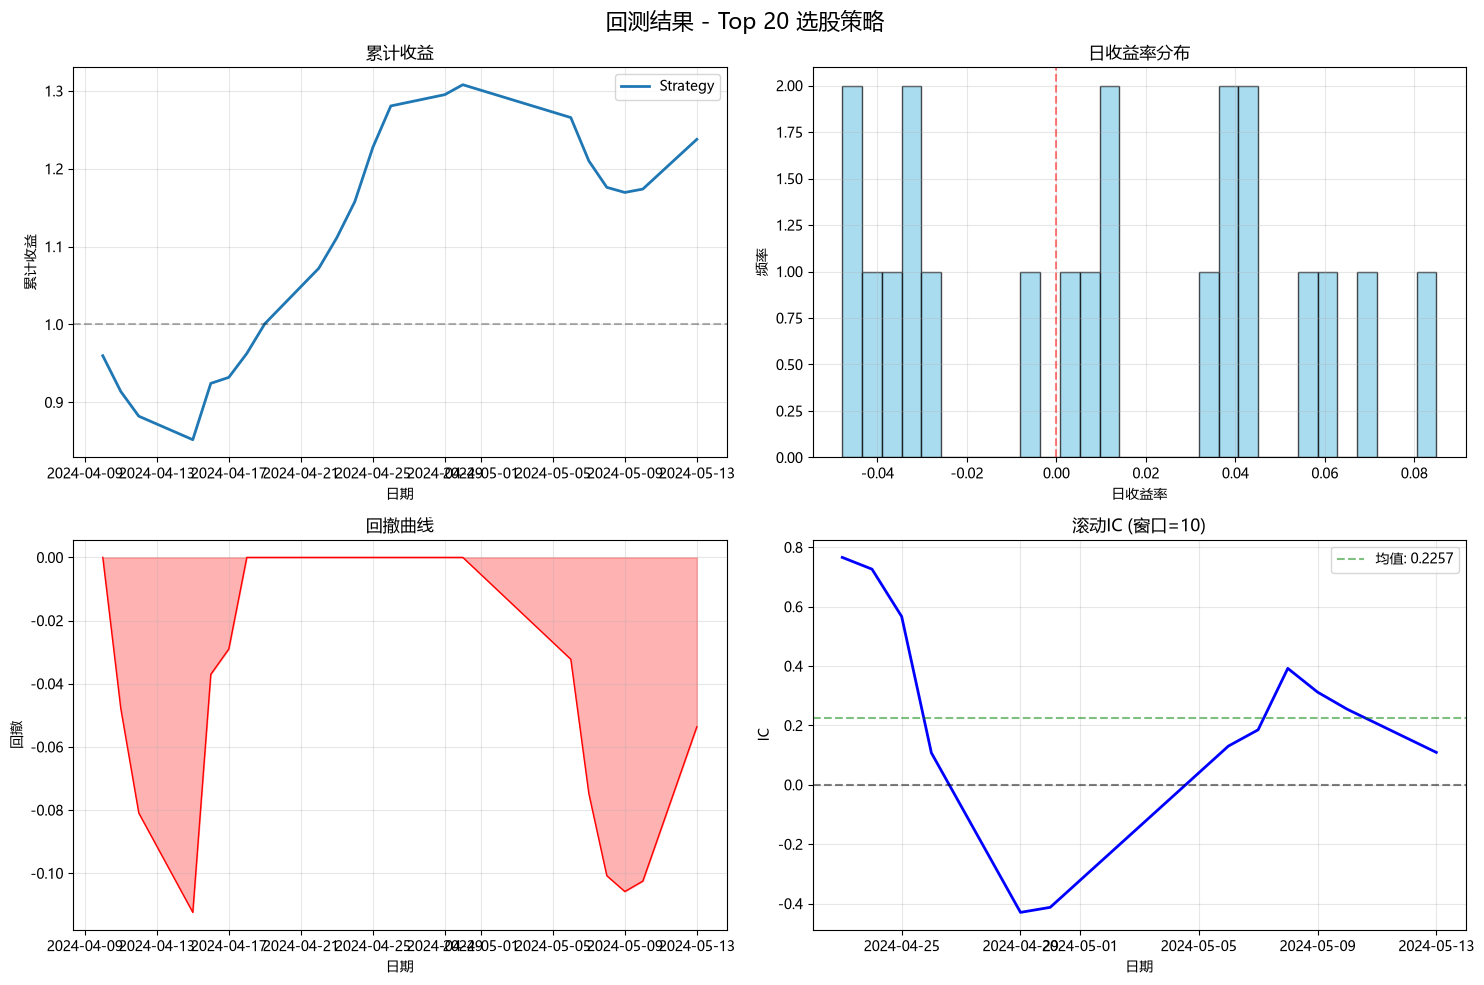


最终回测结果汇总
  总收益率: 23.78%
  年化收益率: 1193.21%
  年化波动率: 65.76%
  夏普比率: 18.1451
  最大回撤: -11.24%
  IC: 0.5704
  预测准确率: 0.5007

生成综合报告...
综合报告已保存至: stk_RF-SVM/reports/final_report.txt

报告摘要
模型表现: 集成准确率 0.5007, 线性基准 0.4893
回测表现: 夏普 18.1451, 最大回撤 -11.24%
IC: 0.5704

保存模型文件...
模型已保存至: stk_RF-SVM/models/final_model.pkl

所有模块执行完成！

生成的文件列表:
------------------------------------------------------------
  ✓ models: stk_RF-SVM/models/final_model.pkl
  ✓ predictions: stk_RF-SVM/predictions/final_predictions.csv
  ✓ feature_importance: stk_RF-SVM/csv/final_feature_importance.csv
  ✓ backtest_summary: stk_RF-SVM/csv/backtest_summary.csv
  ✓ backtest_daily: stk_RF-SVM/csv/backtest_daily_results.csv
  ✗ linear_coefficients: 未生成
  ✓ final_report: stk_RF-SVM/reports/final_report.txt
  ✓ optimization_results: stk_RF-SVM/reports/optimization_results.json
  ✓ backtest_plot: stk_RF-SVM/plots/backtest_results.png

程序执行完毕！


In [29]:
# ==================== 执行完整训练流程 ====================
print("\n" + "="*60)
print("执行完整训练流程（包含所有模块）")
print("="*60)

if len(windows) > 0:
    # 使用第一个窗口
    window = windows[0]
    train_idx = window['train_indices']
    test_idx = window['test_indices']
    
    target_days = 5
    label_key = f'future_{target_days}d_return'
    
    if label_key in labels_dict:
        y = labels_dict[label_key]
        
        X_train = X[train_idx]
        X_test = X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        
        # 划分验证集
        val_size = int(0.2 * len(X_train))
        X_train_final = X_train[:-val_size]
        X_val = X_train[-val_size:]
        y_train_final = y_train[:-val_size]
        y_val = y_train[-val_size:]
        
        print(f"\n数据划分:")
        print(f"  训练集: {len(X_train_final)} 样本")
        print(f"  验证集: {len(X_val)} 样本")
        print(f"  测试集: {len(X_test)} 样本")
        
        # 1. 随机森林超参数调优
        rf_tuning_results = rf_hyperparameter_tuning(X_train_final, y_train_final, X_val, y_val)
        
        # 2. SVM超参数调优
        svm_tuning_results = svm_hyperparameter_tuning(X_train_final, y_train_final, X_val, y_val)
        
        # 3. 训练最终模型
        print("\n" + "="*60)
        print("训练最终模型")
        print("="*60)
        
        # 使用调优后的参数训练随机森林
        print("\n训练随机森林最终模型...")
        rf_reg_final = RandomForestRegressor(**rf_tuning_results['reg_params'], random_state=42, n_jobs=-1)
        rf_reg_final.fit(X_train_final, y_train_final)
        
        rf_clf_final = RandomForestClassifier(**rf_tuning_results['clf_params'], random_state=42, n_jobs=-1)
        rf_clf_final.fit(X_train_final, (y_train_final > 0).astype(int))
        
        # 使用调优后的参数训练SVM
        print("训练SVM最终模型...")
        scaler_svm = StandardScaler()
        X_train_scaled = scaler_svm.fit_transform(X_train_final)
        X_test_scaled = scaler_svm.transform(X_test)
        
        svr_final = SVR(**svm_tuning_results['reg_params'], kernel='rbf')
        svr_final.fit(X_train_scaled, y_train_final)
        
        svc_final = SVC(**svm_tuning_results['clf_params'], kernel='rbf', probability=True, random_state=42)
        svc_final.fit(X_train_scaled, (y_train_final > 0).astype(int))
        
        # 预测
        print("生成预测...")
        rf_pred = rf_reg_final.predict(X_test)
        rf_proba = rf_clf_final.predict_proba(X_test)[:, 1]
        
        X_test_scaled = scaler_svm.transform(X_test)
        svm_pred = svr_final.predict(X_test_scaled)
        svm_proba = svc_final.predict_proba(X_test_scaled)[:, 1]
        
        # 动态权重集成
        lookback = min(30, len(y_test))
        if lookback > 0:
            rf_errors = np.abs(rf_pred[-lookback:] - y_test[-lookback:])
            svm_errors = np.abs(svm_pred[-lookback:] - y_test[-lookback:])
            total_errors = rf_errors + svm_errors
            total_errors = np.where(total_errors == 0, 1e-10, total_errors)
            rf_weight = np.mean(svm_errors / total_errors)
            svm_weight = np.mean(rf_errors / total_errors)
            weight_sum = rf_weight + svm_weight
            rf_weight = rf_weight / weight_sum
            svm_weight = svm_weight / weight_sum
        else:
            rf_weight = 0.5
            svm_weight = 0.5
        
        ensemble_pred = rf_weight * rf_pred + svm_weight * svm_pred
        ensemble_proba = rf_weight * rf_proba + svm_weight * svm_proba
        
        print(f"\n集成权重 - RF: {rf_weight:.4f}, SVM: {svm_weight:.4f}")
        
        # 评估集成模型
        ensemble_mse = mean_squared_error(y_test, ensemble_pred)
        ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
        ensemble_accuracy = accuracy_score((y_test > 0).astype(int), (ensemble_proba > 0.5).astype(int))
        
        print(f"\n集成模型评估:")
        print(f"  MSE: {ensemble_mse:.6f}")
        print(f"  MAE: {ensemble_mae:.6f}")
        print(f"  准确率: {ensemble_accuracy:.4f}")
        
        # 4. 传统线性模型对比
        linear_results = train_linear_model(X_train_final, y_train_final, X_test, y_test, feature_cols)
        
        # 5. 特征重要性
        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': rf_reg_final.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\nTop 10 特征重要性:")
        print(feature_importance.head(10))
        
        # 保存特征重要性
        feature_importance.to_csv('stk_RF-SVM/csv/final_feature_importance.csv', index=False)
        print("特征重要性已保存至: stk_RF-SVM/csv/final_feature_importance.csv")
        
        # 6. 非凸优化（使用部分数据以加快速度）
        print("\n" + "="*60)
        print("执行非凸优化")
        print("="*60)
        
        opt_size = min(2000, len(X_train_final))
        X_opt = X_train_final[:opt_size]
        y_opt = y_train_final[:opt_size]
        val_size_opt = int(0.2 * len(X_opt))
        
        if len(X_opt) > 100:
            optimization_results = nonconvex_optimization_comparison(
                X_opt[:-val_size_opt], y_opt[:-val_size_opt],
                X_opt[-val_size_opt:], y_opt[-val_size_opt:]
            )
        else:
            print("数据量太小，跳过非凸优化")
            optimization_results = None
        
        # 7. 保存所有预测结果
        predictions_df = pd.DataFrame({
            'date': dates[test_idx],
            'code': codes[test_idx],
            'y_true': y_test,
            'rf_pred': rf_pred,
            'svm_pred': svm_pred,
            'ensemble_pred': ensemble_pred,
            'rf_proba': rf_proba,
            'svm_proba': svm_proba,
            'ensemble_proba': ensemble_proba,
            'lr_pred': linear_results['lr_pred'],
            'logit_proba': linear_results['logit_proba']
        })
        
        predictions_df.to_csv('stk_RF-SVM/predictions/final_predictions.csv', index=False)
        print("\n预测结果已保存至: stk_RF-SVM/predictions/final_predictions.csv")
        
        # 8. 执行回测
        print("\n" + "="*60)
        print("执行回测")
        print("="*60)
        backtest_results = backtest_strategy(predictions_df, top_n=20)
        
        if backtest_results:
            print("\n" + "="*60)
            print("最终回测结果汇总")
            print("="*60)
            print(f"  总收益率: {backtest_results['total_return']:.2%}")
            print(f"  年化收益率: {backtest_results['annualized_return']:.2%}")
            print(f"  年化波动率: {backtest_results['volatility']:.2%}")
            print(f"  夏普比率: {backtest_results['sharpe_ratio']:.4f}")
            print(f"  最大回撤: {backtest_results['max_drawdown']:.2%}")
            print(f"  IC: {backtest_results['ic']:.4f}")
            print(f"  预测准确率: {backtest_results['accuracy']:.4f}")
            
            # 9. 生成综合报告
            print("\n生成综合报告...")
            report = f"""
            ========================================
            机器学习量化选股系统 - 综合报告
            ========================================
            
            数据信息:
              数据范围: {dates.min()} 到 {dates.max()}
              股票数量: {len(np.unique(codes))}
              总样本数: {len(X)}
              总交易日数: {len(np.unique(dates))}
            
            模型配置:
              目标周期: {target_days}天收益率
              训练集大小: {len(X_train_final)}
              验证集大小: {len(X_val)}
              测试集大小: {len(X_test)}
            
            随机森林参数:
              回归: {rf_tuning_results['reg_params']}
              分类: {rf_tuning_results['clf_params']}
              回归MSE: {rf_tuning_results['reg_score']:.6f}
              分类准确率: {rf_tuning_results['clf_score']:.4f}
            
            SVM参数:
              回归: {svm_tuning_results['reg_params']}
              分类: {svm_tuning_results['clf_params']}
              回归MSE: {svm_tuning_results['reg_score']:.6f}
              分类准确率: {svm_tuning_results['clf_score']:.4f}
            
            集成权重:
              RF: {rf_weight:.4f}
              SVM: {svm_weight:.4f}
            
            模型表现对比:
              集成模型 - MSE: {ensemble_mse:.6f}, 准确率: {ensemble_accuracy:.4f}
              线性回归 - MSE: {linear_results['lr_mse']:.6f}
              逻辑回归 - 准确率: {linear_results['logit_accuracy']:.4f}
            
            """
            
            if optimization_results:
                report += f"""
            非凸优化结果:
              随机森林:
                遗传算法最优准确率: {optimization_results['rf_genetic']['accuracy']:.4f}
                模拟退火最优准确率: {optimization_results['rf_annealing']['accuracy']:.4f}
                遗传算法耗时: {optimization_results['rf_genetic']['time']:.2f}秒
                模拟退火耗时: {optimization_results['rf_annealing']['time']:.2f}秒
              
              SVM:
                遗传算法最优准确率: {optimization_results['svm_genetic']['accuracy']:.4f}
                模拟退火最优准确率: {optimization_results['svm_annealing']['accuracy']:.4f}
                遗传算法耗时: {optimization_results['svm_genetic']['time']:.2f}秒
                模拟退火耗时: {optimization_results['svm_annealing']['time']:.2f}秒
            """
            
            report += f"""
            回测结果 (Top 20):
              总收益率: {backtest_results['total_return']:.2%}
              年化收益率: {backtest_results['annualized_return']:.2%}
              年化波动率: {backtest_results['volatility']:.2%}
              夏普比率: {backtest_results['sharpe_ratio']:.4f}
              最大回撤: {backtest_results['max_drawdown']:.2%}
              IC: {backtest_results['ic']:.4f}
              预测准确率: {backtest_results['accuracy']:.4f}
            
            Top 10 重要特征:
            {feature_importance.head(10).to_string(index=False)}
            
            ========================================
            """
            
            # 保存报告
            with open('stk_RF-SVM/reports/final_report.txt', 'w', encoding='utf-8') as f:
                f.write(report)
            print("综合报告已保存至: stk_RF-SVM/reports/final_report.txt")
            
            # 打印报告摘要
            print("\n" + "="*60)
            print("报告摘要")
            print("="*60)
            print(f"模型表现: 集成准确率 {ensemble_accuracy:.4f}, 线性基准 {linear_results['logit_accuracy']:.4f}")
            print(f"回测表现: 夏普 {backtest_results['sharpe_ratio']:.4f}, 最大回撤 {backtest_results['max_drawdown']:.2%}")
            print(f"IC: {backtest_results['ic']:.4f}")
            print("="*60)
        
        # 10. 保存模型文件
        print("\n保存模型文件...")
        import pickle
        
        model_dict = {
            'rf_reg': rf_reg_final,
            'rf_clf': rf_clf_final,
            'svr': svr_final,
            'svc': svc_final,
            'scaler_svm': scaler_svm,
            'rf_weight': rf_weight,
            'svm_weight': svm_weight,
            'feature_cols': feature_cols,
            'target_days': target_days,
            'rf_params': rf_tuning_results['reg_params'],
            'svm_params': svm_tuning_results['reg_params'],
            'ensemble_accuracy': ensemble_accuracy,
            'backtest_results': backtest_results
        }
        
        with open('stk_RF-SVM/models/final_model.pkl', 'wb') as f:
            pickle.dump(model_dict, f)
        print("模型已保存至: stk_RF-SVM/models/final_model.pkl")
        
    else:
        print(f"标签 {label_key} 不存在")
else:
    print("没有可用的滚动窗口，尝试使用时间序列交叉验证...")
    
    # 使用时间序列交叉验证
    from sklearn.model_selection import TimeSeriesSplit
    
    target_days = 5
    label_key = f'future_{target_days}d_return'
    
    if label_key in labels_dict:
        y = labels_dict[label_key]
        non_zero = np.sum(y != 0)
        
        if non_zero > 100:
            print(f"\n使用全部数据进行时间序列交叉验证...")
            
            # 使用TimeSeriesSplit
            tscv = TimeSeriesSplit(n_splits=3)
            
            all_predictions = []
            all_actuals = []
            all_dates = []
            all_codes = []
            fold_results = []
            
            for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
                X_train = X[train_idx]
                X_test = X[test_idx]
                y_train = y[train_idx]
                y_test = y[test_idx]
                
                if len(train_idx) > 50 and len(test_idx) > 10:
                    print(f"\nFold {fold+1}: 训练 {len(train_idx)} 样本, 测试 {len(test_idx)} 样本")
                    
                    # 训练模型
                    results = train_adaptive_model(X_train, y_train, X_test, y_test, feature_cols, fold, target_days)
                    
                    all_predictions.extend(results['ensemble_pred'])
                    all_actuals.extend(y_test)
                    all_dates.extend(dates[test_idx])
                    all_codes.extend(codes[test_idx])
                    
                    fold_results.append({
                        'fold': fold+1,
                        'accuracy': results['ensemble_accuracy'],
                        'rf_mse': results['rf_mse'],
                        'svm_mse': results['svm_mse'],
                        'n_train': len(train_idx),
                        'n_test': len(test_idx)
                    })
            
            if len(all_predictions) > 0:
                # 整体评估
                mse = mean_squared_error(all_actuals, all_predictions)
                accuracy = accuracy_score((np.array(all_actuals) > 0).astype(int), 
                                        (np.array(all_predictions) > 0).astype(int))
                
                print(f"\n交叉验证结果:")
                print(f"  MSE: {mse:.6f}")
                print(f"  准确率: {accuracy:.4f}")
                
                # 显示各Fold结果
                fold_df = pd.DataFrame(fold_results)
                print(f"\n各Fold结果:")
                print(fold_df.to_string(index=False))
                
                # 保存所有预测结果
                cv_predictions_df = pd.DataFrame({
                    'date': all_dates,
                    'code': all_codes,
                    'y_true': all_actuals,
                    'ensemble_pred': all_predictions
                })
                cv_predictions_df.to_csv('stk_RF-SVM/csv/cv_predictions.csv', index=False)
                
                # 保存Fold结果
                fold_df.to_csv('stk_RF-SVM/csv/fold_results.csv', index=False)
                print("\n交叉验证结果已保存")
                
                # 执行回测
                backtest_results = backtest_strategy(cv_predictions_df, top_n=20)
                
                if backtest_results:
                    print("\n回测完成！")
                    print(f"  总收益率: {backtest_results['total_return']:.2%}")
                    print(f"  年化收益率: {backtest_results['annualized_return']:.2%}")
                    print(f"  夏普比率: {backtest_results['sharpe_ratio']:.4f}")
                    print(f"  最大回撤: {backtest_results['max_drawdown']:.2%}")
        else:
            print(f"标签非零值太少: {non_zero}")
    else:
        print(f"标签 {label_key} 不存在")

print("\n" + "="*60)
print("所有模块执行完成！")
print("="*60)

# 显示所有输出文件
print("\n生成的文件列表:")
print("-"*60)

output_files = {
    'models': 'stk_RF-SVM/models/final_model.pkl',
    'predictions': 'stk_RF-SVM/predictions/final_predictions.csv',
    'feature_importance': 'stk_RF-SVM/csv/final_feature_importance.csv',
    'backtest_summary': 'stk_RF-SVM/csv/backtest_summary.csv',
    'backtest_daily': 'stk_RF-SVM/csv/backtest_daily_results.csv',
    'linear_coefficients': 'stk_RF-SVM/csv/linear_coefficients.csv',
    'final_report': 'stk_RF-SVM/reports/final_report.txt',
    'optimization_results': 'stk_RF-SVM/reports/optimization_results.json',
    'backtest_plot': 'stk_RF-SVM/plots/backtest_results.png'
}

for name, path in output_files.items():
    if os.path.exists(path):
        print(f"  ✓ {name}: {path}")
    else:
        print(f"  ✗ {name}: 未生成")

print("\n" + "="*60)
print("程序执行完毕！")
print("="*60)